# Scenario 1: Association Rule Mining

## Import required libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

## Load dataset

In [ ]:
df = pd.read_csv('/content/Groceries_dataset.csv')
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


## Data preprocessing (group transactions & one-hot encoding)

In [ ]:
transactions = df.groupby('Member_number')['itemDescription'].apply(list).values

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Generate frequent itemsets

In [ ]:
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
frequent_itemsets.head()

,support,itemsets
0,0.015393,(Instant food products)
1,0.078502,(UHT-milk)
2,0.031042,(baking powder)
3,0.119548,(beef)
4,0.079785,(berries)


## Generate association rules

In [ ]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(UHT-milk),(other vegetables),0.078502,0.376603,0.038994,0.496732,1.318979,1.0,0.009430,1.238697,0.262440,0.093711,0.192700,0.300137
1,(UHT-milk),(rolls/buns),0.078502,0.349666,0.031042,0.395425,1.130863,1.0,0.003592,1.075687,0.125578,0.078165,0.070361,0.242100
2,(UHT-milk),(soda),0.078502,0.313494,0.027450,0.349673,1.115406,1.0,0.002840,1.055632,0.112280,0.075299,0.052700,0.218617
3,(UHT-milk),(whole milk),0.078502,0.458184,0.040534,0.516340,1.126928,1.0,0.004565,1.120242,0.122227,0.081696,0.107336,0.302403
4,(baking powder),(other vegetables),0.031042,0.376603,0.015136,0.487603,1.294740,1.0,0.003446,1.216629,0.234937,0.038562,0.178057,0.263897


## Filter rules using lift

In [ ]:
strong_rules = rules[rules['lift'] > 1]
strong_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(UHT-milk),(other vegetables),0.078502,0.376603,0.038994,0.496732,1.318979,1.0,0.009430,1.238697,0.262440,0.093711,0.192700,0.300137
1,(UHT-milk),(rolls/buns),0.078502,0.349666,0.031042,0.395425,1.130863,1.0,0.003592,1.075687,0.125578,0.078165,0.070361,0.242100
2,(UHT-milk),(soda),0.078502,0.313494,0.027450,0.349673,1.115406,1.0,0.002840,1.055632,0.112280,0.075299,0.052700,0.218617
3,(UHT-milk),(whole milk),0.078502,0.458184,0.040534,0.516340,1.126928,1.0,0.004565,1.120242,0.122227,0.081696,0.107336,0.302403
4,(baking powder),(other vegetables),0.031042,0.376603,0.015136,0.487603,1.294740,1.0,0.003446,1.216629,0.234937,0.038562,0.178057,0.263897


## Visualization: Frequent itemsets

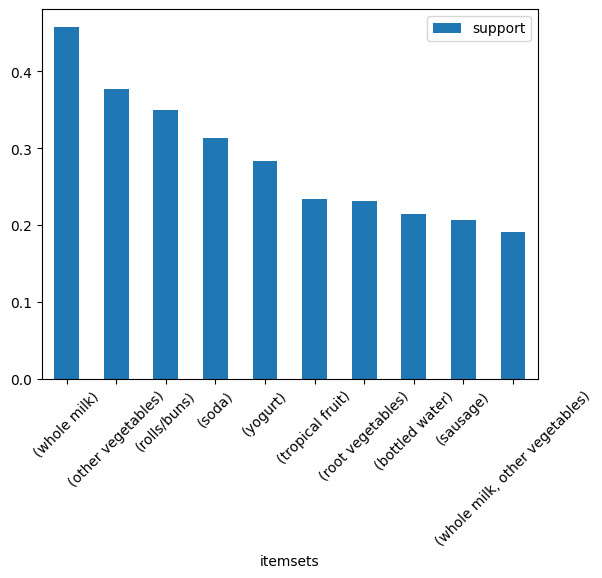

In [ ]:
frequent_itemsets.sort_values(by='support', ascending=False).head(10).plot(kind='bar', x='itemsets', y='support')
plt.xticks(rotation=45)
plt.show()

## Support vs Confidence plot

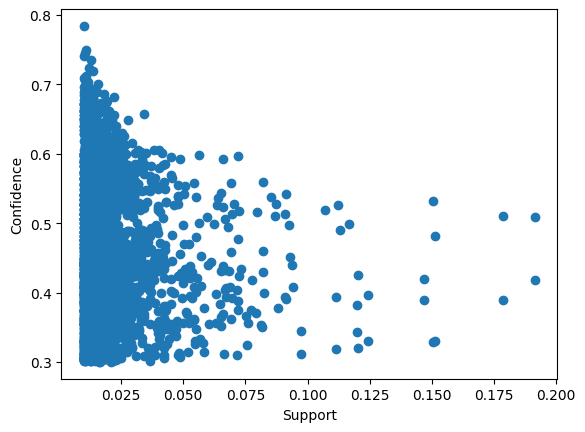

In [ ]:
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

## Analysis: Effect of Support Threshold

In [ ]:
supports = [0.01, 0.02, 0.05]
for s in supports:
    fi = apriori(df_encoded, min_support=s, use_colnames=True)
    print(f'Support={s} -> Number of itemsets:', len(fi))

Support=0.01 -> Number of itemsets: 3016
Support=0.02 -> Number of itemsets: 894
Support=0.05 -> Number of itemsets: 165


## Identify Strong Association Rules

In [ ]:
strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1)]
strong_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(UHT-milk),(whole milk),0.078502,0.458184,0.040534,0.516340,1.126928,1.0,0.004565,1.120242,0.122227,0.081696,0.107336,0.302403
12,(beef),(whole milk),0.119548,0.458184,0.064135,0.536481,1.170886,1.0,0.009360,1.168919,0.165762,0.124875,0.144508,0.338229
27,(bottled beer),(whole milk),0.158799,0.458184,0.085428,0.537964,1.174124,1.0,0.012669,1.172672,0.176297,0.160714,0.147247,0.362207
34,(bottled water),(whole milk),0.213699,0.458184,0.112365,0.525810,1.147597,1.0,0.014452,1.142615,0.163569,0.200825,0.124815,0.385526
39,(brown bread),(whole milk),0.135967,0.458184,0.069779,0.513208,1.120091,1.0,0.007481,1.113034,0.124087,0.133072,0.101554,0.332752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3383,"(whole milk, other vegetables, shopping bags, ...",(rolls/buns),0.017958,0.349666,0.010005,0.557143,1.593355,1.0,0.003726,1.468495,0.379203,0.027977,0.319031,0.292878
3385,"(rolls/buns, whole milk, yogurt, shopping bags)",(other vegetables),0.016932,0.376603,0.010005,0.590909,1.569049,1.0,0.003629,1.523858,0.368918,0.026087,0.343771,0.308738
3386,"(rolls/buns, yogurt, other vegetables, shoppin...",(whole milk),0.014110,0.458184,0.010005,0.709091,1.547613,1.0,0.003540,1.862494,0.358908,0.021643,0.463085,0.365464
3393,"(rolls/buns, whole milk, yogurt, soda)",(other vegetables),0.024628,0.376603,0.013597,0.552083,1.465954,1.0,0.004322,1.391769,0.325876,0.035076,0.281490,0.294093


## Compare Rules with Different Confidence Levels

In [ ]:
conf_levels = [0.3, 0.5, 0.7]
for c in conf_levels:
    r = association_rules(frequent_itemsets, metric='confidence', min_threshold=c)
    print(f'Confidence={c} -> Rules:', len(r))

Confidence=0.3 -> Rules: 3398
Confidence=0.5 -> Rules: 1117
Confidence=0.7 -> Rules: 14


## Real-world Interpretation

In [ ]:
for _, row in strong_rules.head(5).iterrows():
    print(f"If {set(row['antecedents'])} then {set(row['consequents'])} | Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")

If {'UHT-milk'} then {'whole milk'} | Confidence: 0.52, Lift: 1.13
If {'beef'} then {'whole milk'} | Confidence: 0.54, Lift: 1.17
If {'bottled beer'} then {'whole milk'} | Confidence: 0.54, Lift: 1.17
If {'bottled water'} then {'whole milk'} | Confidence: 0.53, Lift: 1.15
If {'brown bread'} then {'whole milk'} | Confidence: 0.51, Lift: 1.12


## Network Graph of Association Rules

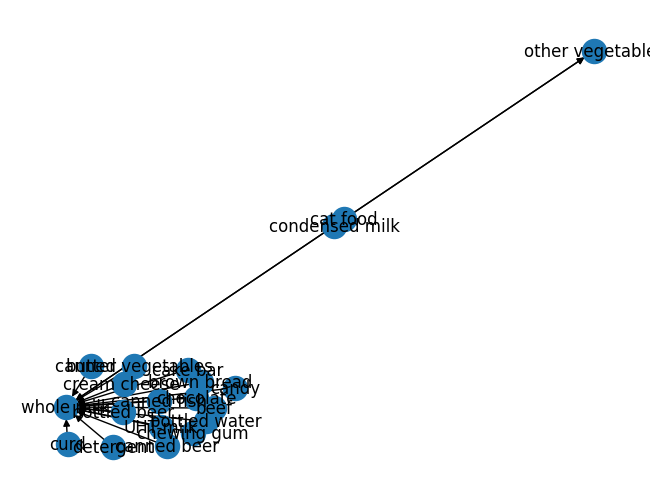

In [ ]:
import networkx as nx
G = nx.DiGraph()
for _, row in strong_rules.head(20).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])
nx.draw(G, with_labels=True)
plt.show()